In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# --- Load datasets ---
socat_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SOCAT/SOCAT_combined.xlsx"
sanae_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Combined_Underway_clean.xlsx"

df_socat = pd.read_excel(socat_path)
df_sanae = pd.read_excel(sanae_path)

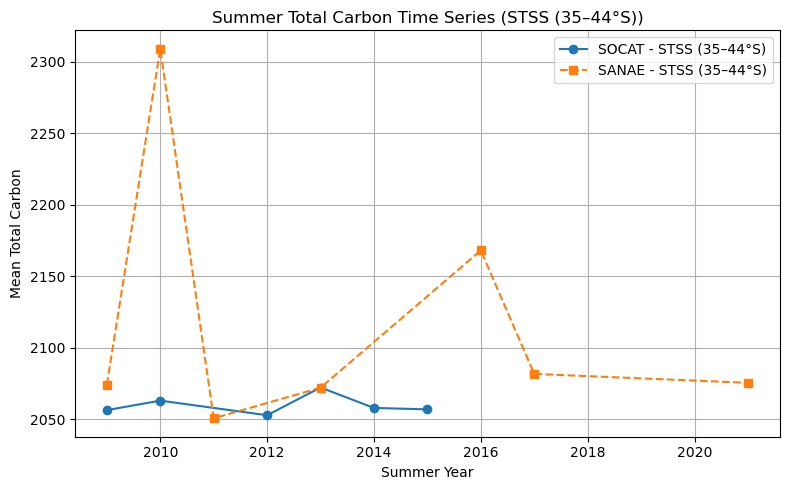

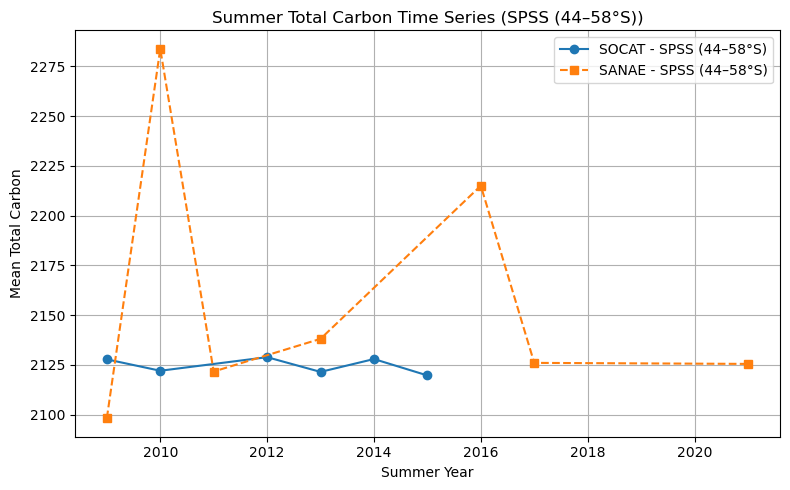

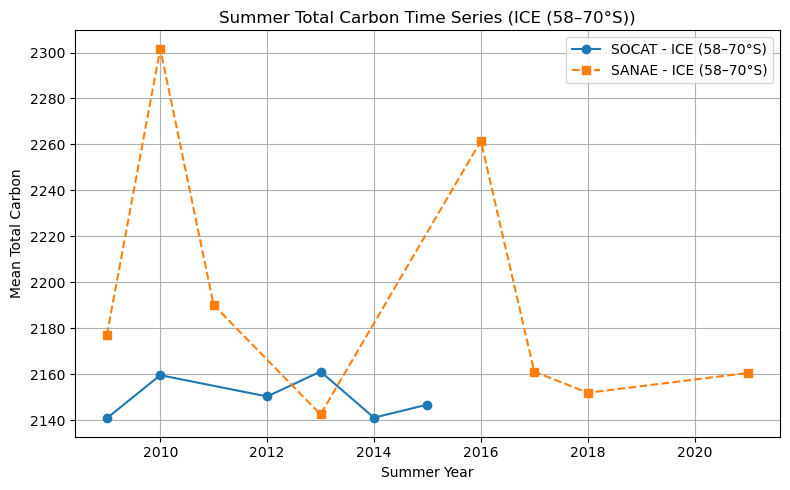

In [4]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),  # leap year
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),  # leap year
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),  # leap year
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Aggregate mean Total Carbon per summer year and biome ---
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['Total Carbon'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['Total Carbon'].mean().reset_index()

# --- Plot separate figures per biome ---
for biome in biome_order:
    plt.figure(figsize=(8,5))
    
    plt.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
             soc_summary[soc_summary['Biome']==biome]['Total Carbon'],
             linestyle='-', marker='o', label=f"SOCAT - {biome}")
    
    plt.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
             san_summary[san_summary['Biome']==biome]['Total Carbon'],
             linestyle='--', marker='s', label=f"SANAE - {biome}")
    
    plt.xlabel("Summer Year")
    plt.ylabel("Mean Total Carbon")
    plt.title(f"Summer Total Carbon Time Series ({biome})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


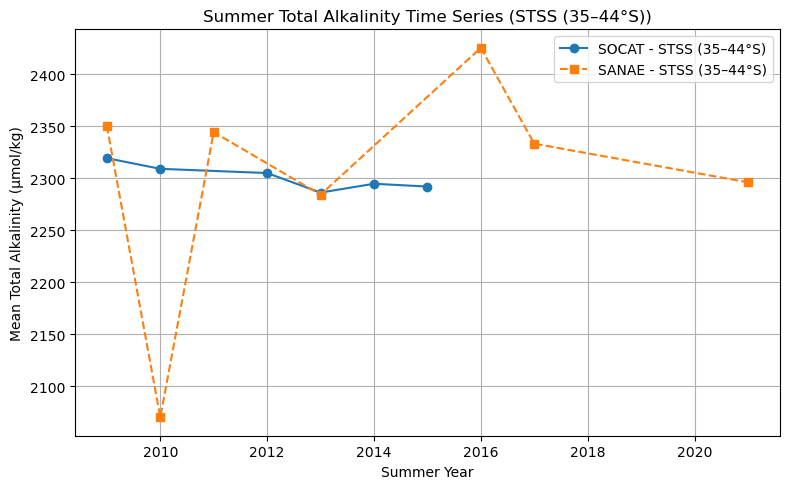

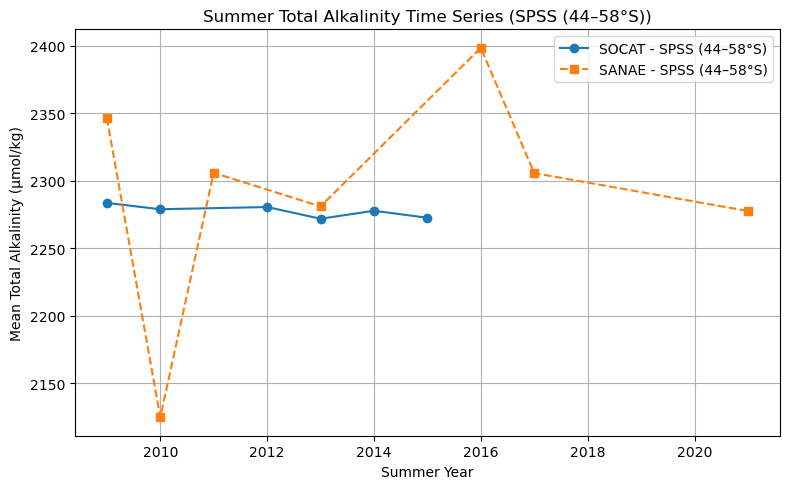

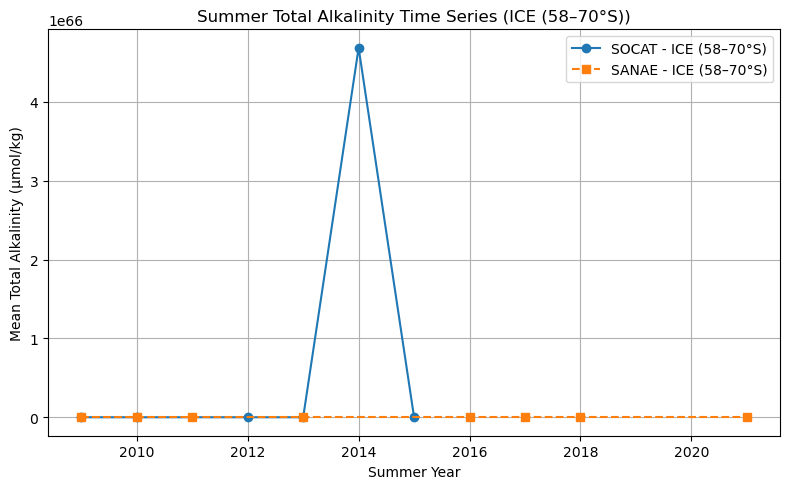

In [5]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),  # leap year
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),  # leap year
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),  # leap year
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Aggregate mean Total Carbon per summer year and biome ---
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['Total Alkalinity'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['Total Alkalinity'].mean().reset_index()

# --- Plot separate figures per biome ---
for biome in biome_order:
    plt.figure(figsize=(8,5))
    
    plt.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
             soc_summary[soc_summary['Biome']==biome]['Total Alkalinity'],
             linestyle='-', marker='o', label=f"SOCAT - {biome}")
    
    plt.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
             san_summary[san_summary['Biome']==biome]['Total Alkalinity'],
             linestyle='--', marker='s', label=f"SANAE - {biome}")
    
    plt.xlabel("Summer Year")
    plt.ylabel("Mean Total Alkalinity (µmol/kg)")
    plt.title(f"Summer Total Alkalinity Time Series ({biome})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


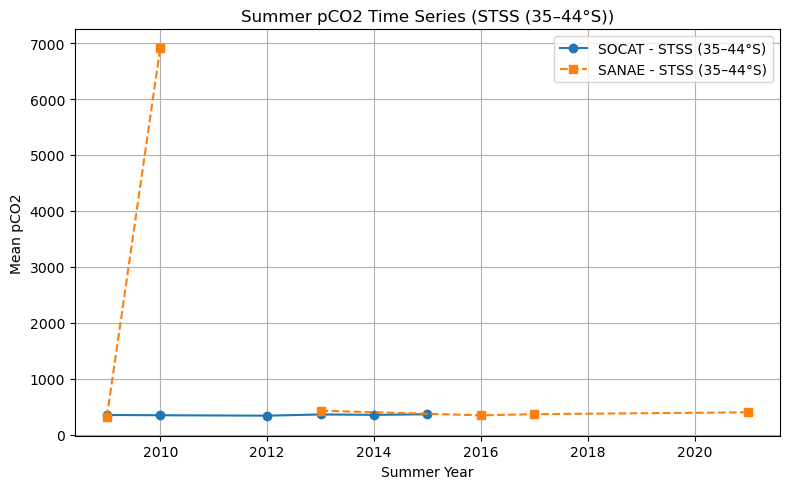

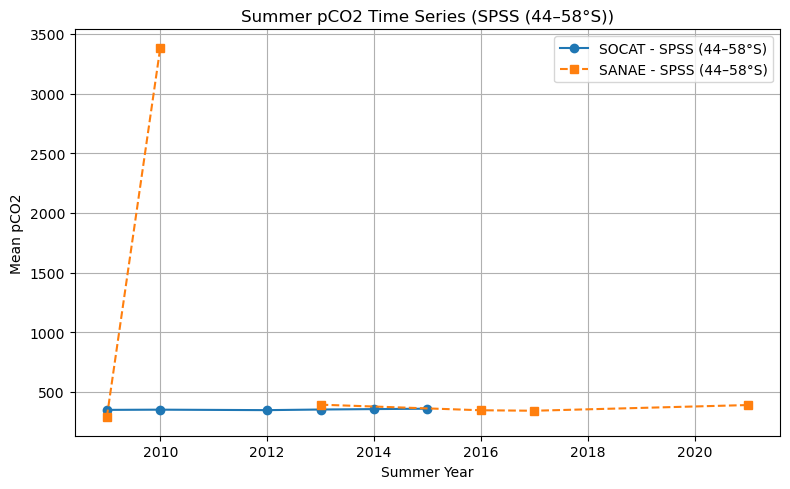

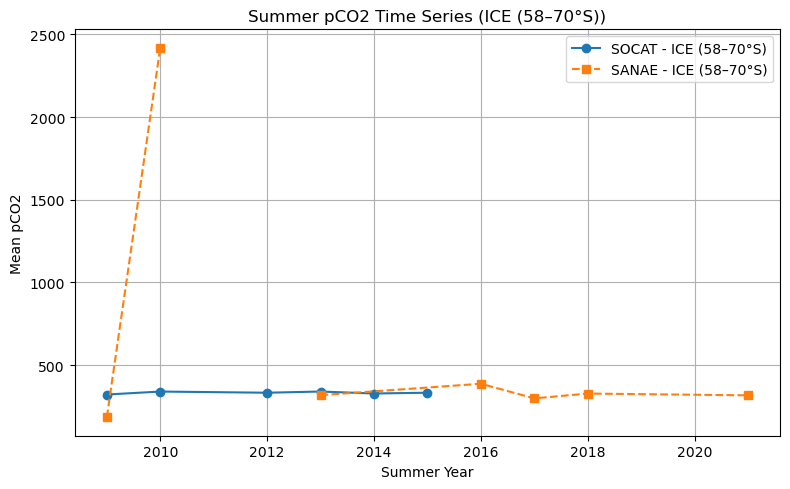

In [6]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),  # leap year
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),  # leap year
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),  # leap year
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Aggregate mean Total Carbon per summer year and biome ---
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['pCO2'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['pCO2'].mean().reset_index()

# --- Plot separate figures per biome ---
for biome in biome_order:
    plt.figure(figsize=(8,5))
    
    plt.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
             soc_summary[soc_summary['Biome']==biome]['pCO2'],
             linestyle='-', marker='o', label=f"SOCAT - {biome}")
    
    plt.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
             san_summary[san_summary['Biome']==biome]['pCO2'],
             linestyle='--', marker='s', label=f"SANAE - {biome}")
    
    plt.xlabel("Summer Year")
    plt.ylabel("Mean pCO2")
    plt.title(f"Summer pCO2 Time Series ({biome})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


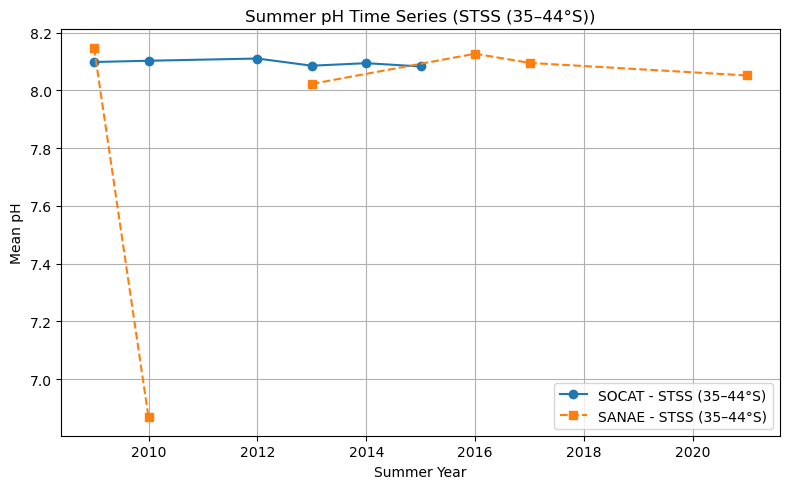

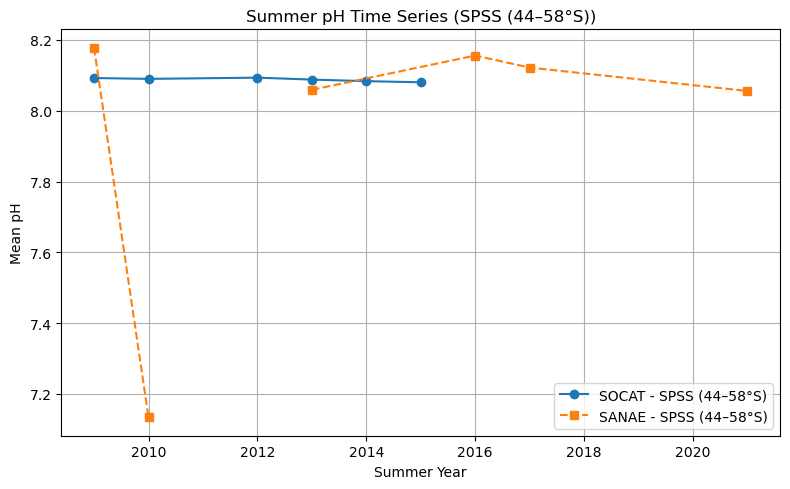

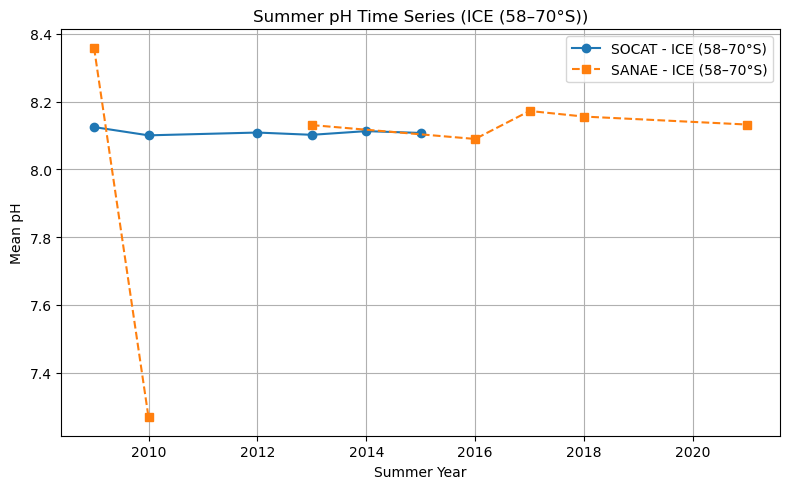

In [7]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),  # leap year
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),  # leap year
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),  # leap year
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Aggregate mean Total Carbon per summer year and biome ---
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['pH'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['pH'].mean().reset_index()

# --- Plot separate figures per biome ---
for biome in biome_order:
    plt.figure(figsize=(8,5))
    
    plt.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
             soc_summary[soc_summary['Biome']==biome]['pH'],
             linestyle='-', marker='o', label=f"SOCAT - {biome}")
    
    plt.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
             san_summary[san_summary['Biome']==biome]['pH'],
             linestyle='--', marker='s', label=f"SANAE - {biome}")
    
    plt.xlabel("Summer Year")
    plt.ylabel("Mean pH")
    plt.title(f"Summer pH Time Series ({biome})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

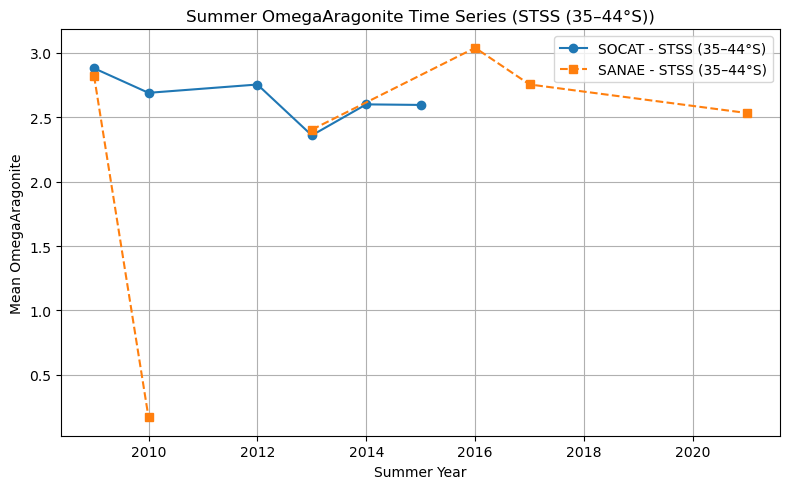

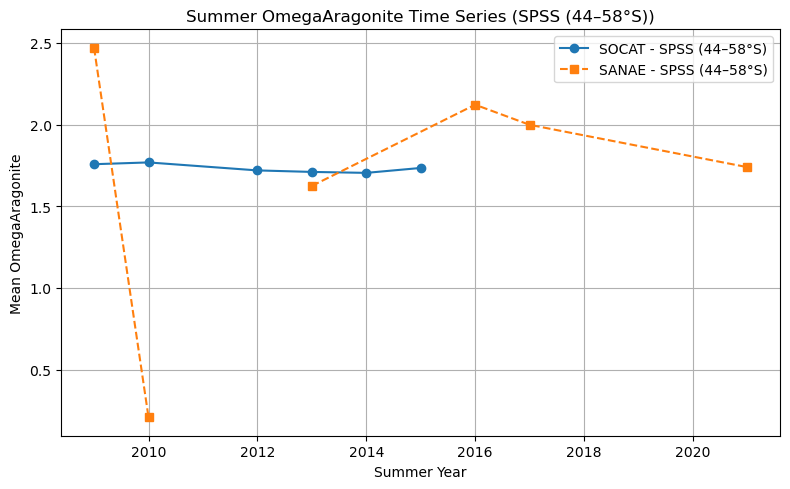

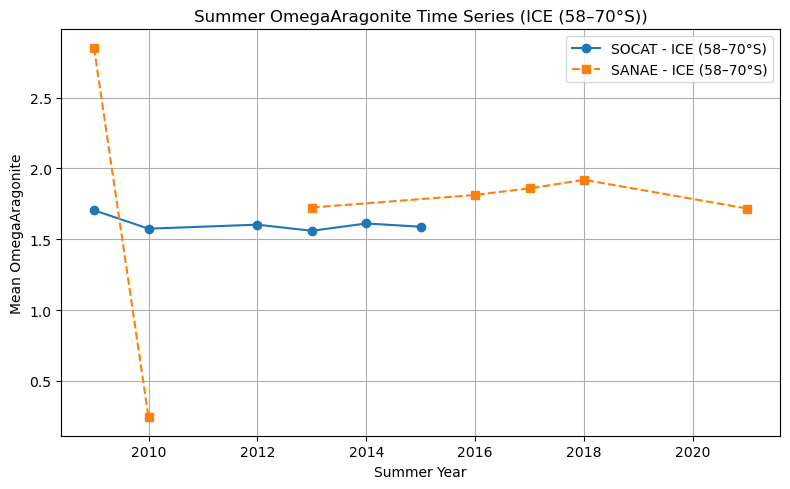

In [8]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),  # leap year
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),  # leap year
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),  # leap year
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Aggregate mean Total Carbon per summer year and biome ---
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['OmegaAragonite'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['OmegaAragonite'].mean().reset_index()

# --- Plot separate figures per biome ---
for biome in biome_order:
    plt.figure(figsize=(8,5))
    
    plt.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
             soc_summary[soc_summary['Biome']==biome]['OmegaAragonite'],
             linestyle='-', marker='o', label=f"SOCAT - {biome}")
    
    plt.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
             san_summary[san_summary['Biome']==biome]['OmegaAragonite'],
             linestyle='--', marker='s', label=f"SANAE - {biome}")
    
    plt.xlabel("Summer Year")
    plt.ylabel("Mean OmegaAragonite")
    plt.title(f"Summer OmegaAragonite Time Series ({biome})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

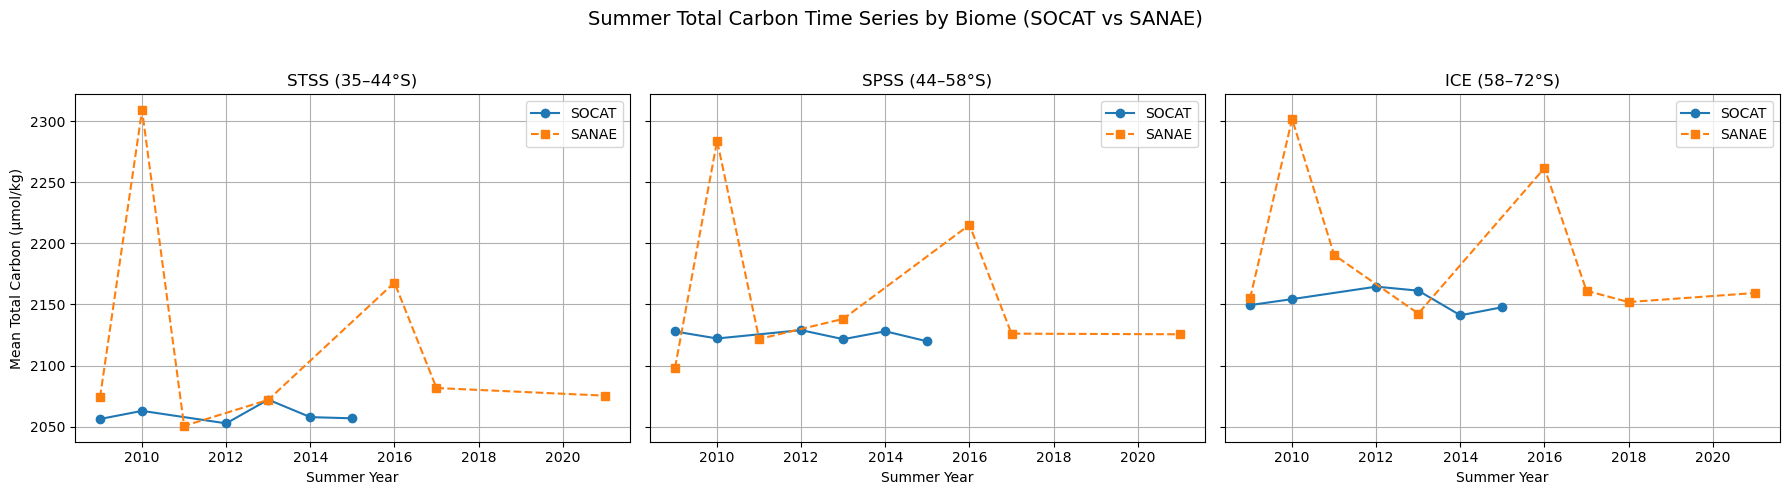

In [16]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -72 <= lat < -58:
        return "ICE (58–72°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),  # leap year
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),  # leap year
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),  # leap year
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–72°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Aggregate mean Total Carbon per summer year and biome ---
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['Total Carbon'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['Total Carbon'].mean().reset_index()

# --- Plot 1 row × 3 columns ---
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for i, biome in enumerate(biome_order):
    ax = axes[i]
    
    ax.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
            soc_summary[soc_summary['Biome']==biome]['Total Carbon'],
            linestyle='-', marker='o', label="SOCAT")
    
    ax.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
            san_summary[san_summary['Biome']==biome]['Total Carbon'],
            linestyle='--', marker='s', label="SANAE")
    
    ax.set_title(biome)
    ax.set_xlabel("Summer Year")
    if i == 0:
        ax.set_ylabel("Mean Total Carbon (µmol/kg)")
    ax.grid(True)
    ax.legend()

plt.suptitle("Summer Total Carbon Time Series by Biome (SOCAT vs SANAE)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])

# --- Save figure ---
plt.savefig("TotalCarbon_TimeSeries_Biomes.png", dpi=600)
plt.savefig("TotalCarbon_TimeSeries_Biomes.pdf")

plt.show()


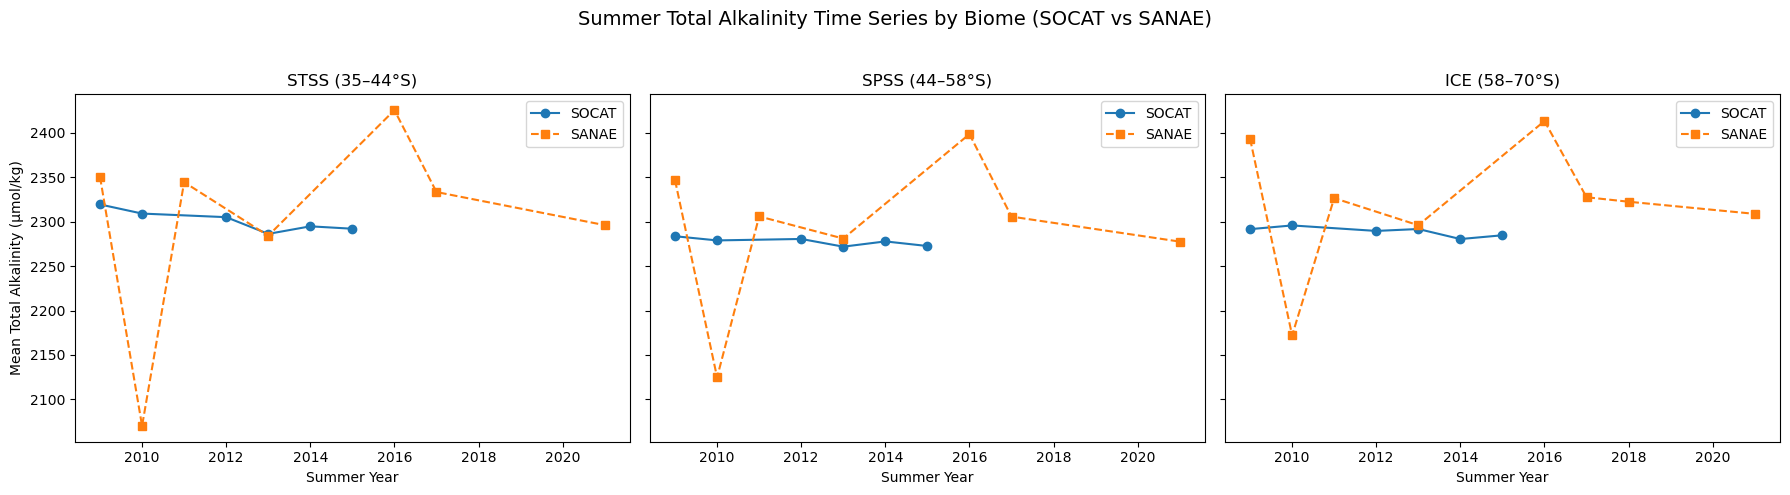

<Figure size 640x480 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load datasets ---
socat_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SOCAT/SOCAT_combined.xlsx"
sanae_path = "/Users/Mbongeleni/Library/CloudStorage/OneDrive-StellenboschUniversity/Documents/CSIR/SANAE/SANAE_Combined_Underway_clean.xlsx"

df_socat = pd.read_excel(socat_path)
df_sanae = pd.read_excel(sanae_path)

# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -70 <= lat < -58:
        return "ICE (58–70°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Ensure numeric column ---
df_socat_summer['Total Alkalinity'] = pd.to_numeric(df_socat_summer['Total Alkalinity'], errors='coerce')
df_sanae_summer['Total Alkalinity'] = pd.to_numeric(df_sanae_summer['Total Alkalinity'], errors='coerce')

# Define plausible range
TA_min, TA_max = 2000, 2700

# Exclude out-of-range ICE values
df_socat_summer = df_socat_summer[
    ~((df_socat_summer['Biome']=="ICE (58–70°S)") &
      ((df_socat_summer['Total Alkalinity'] < TA_min) | (df_socat_summer['Total Alkalinity'] > TA_max)))
]

df_sanae_summer = df_sanae_summer[
    ~((df_sanae_summer['Biome']=="ICE (58–70°S)") &
      ((df_sanae_summer['Total Alkalinity'] < TA_min) | (df_sanae_summer['Total Alkalinity'] > TA_max)))
]


# Aggregate again
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['Total Alkalinity'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['Total Alkalinity'].mean().reset_index()

# Plot (1 row × 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for i, biome in enumerate(["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–70°S)"]):
    ax = axes[i]
    
    ax.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
            soc_summary[soc_summary['Biome']==biome]['Total Alkalinity'],
            linestyle='-', marker='o', label="SOCAT")
    
    ax.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
            san_summary[san_summary['Biome']==biome]['Total Alkalinity'],
            linestyle='--', marker='s', label="SANAE")
    
    ax.set_title(biome)
    ax.set_xlabel("Summer Year")
    if i == 0:
        ax.set_ylabel("Mean Total Alkalinity (µmol/kg)")
    ax.grid(False)
    ax.legend()

plt.suptitle("Summer Total Alkalinity Time Series by Biome (SOCAT vs SANAE)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# --- Save figure ---
plt.savefig("TotalAlkalinity_TimeSeries_Biomes.png", dpi=600)
plt.savefig("TotalAlkalinity_TimeSeries_Biomes.pdf")

plt.show()

In [11]:
# Check descriptive stats for ICE biome
print("SOCAT ICE TA summary:")
print(df_socat_summer[df_socat_summer['Biome']=="ICE (58–70°S)"]['Total Alkalinity'].describe())

print("\nSANAE ICE TA summary:")
print(df_sanae_summer[df_sanae_summer['Biome']=="ICE (58–70°S)"]['Total Alkalinity'].describe())

SOCAT ICE TA summary:
count    44827.000000
mean      2289.412429
std         17.101077
min       2102.346336
25%       2282.070813
50%       2290.795928
75%       2298.294560
max       2689.702371
Name: Total Alkalinity, dtype: float64

SANAE ICE TA summary:
count     257.000000
mean     2303.186677
std        73.756859
min      2079.950292
25%      2285.910000
50%      2315.112443
75%      2337.169251
max      2481.099402
Name: Total Alkalinity, dtype: float64


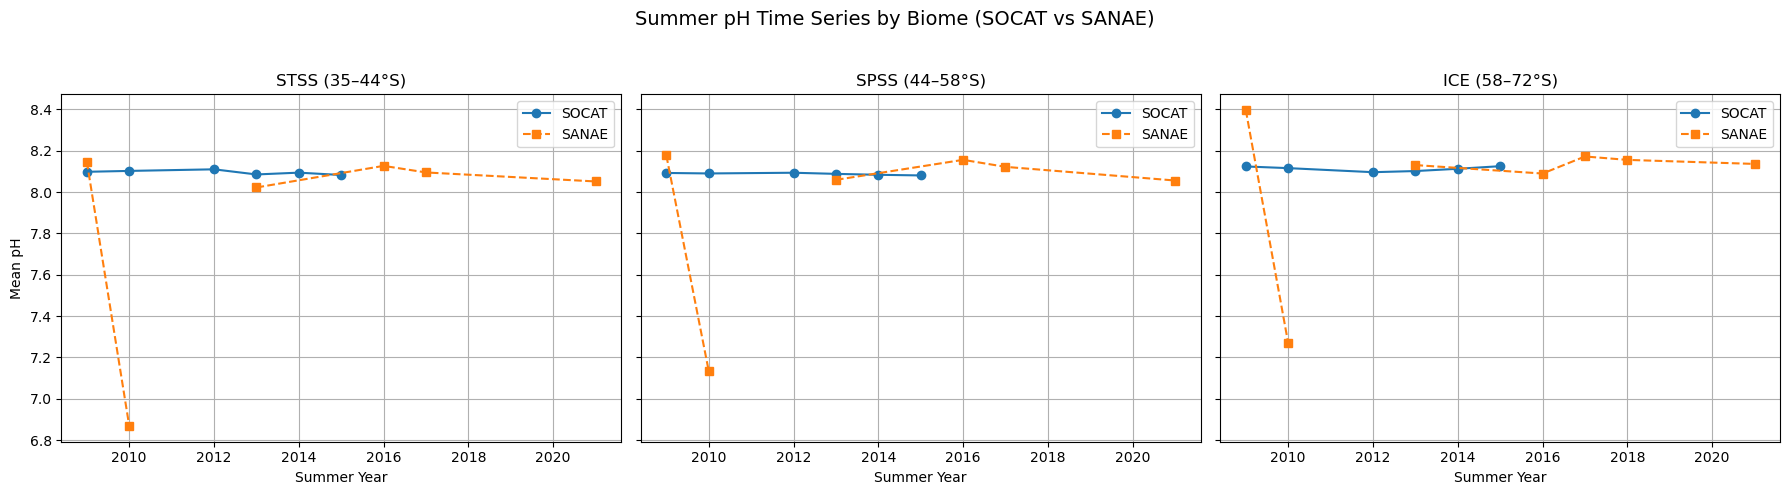

<Figure size 640x480 with 0 Axes>

In [14]:
# --- Parse dates ---
df_socat['Date'] = pd.to_datetime(df_socat['Date'])
df_sanae['Date'] = pd.to_datetime(df_sanae['Date'])

# --- Define biome assignment ---
def assign_biome(lat):
    if -44 <= lat < -35:
        return "STSS (35–44°S)"
    elif -58 <= lat < -44:
        return "SPSS (44–58°S)"
    elif -72 <= lat < -58:
        return "ICE (58–72°S)"
    else:
        return "Outside Defined Biome"

# --- Define summers (Dec–Feb windows) ---
summer_ranges = {
    2009: ('2009-12-01', '2010-02-28'),
    2010: ('2010-12-01', '2011-02-28'),
    2011: ('2011-12-01', '2012-02-29'),
    2012: ('2012-12-01', '2013-02-28'),
    2013: ('2013-12-01', '2014-02-28'),
    2014: ('2014-12-01', '2015-02-28'),
    2015: ('2015-12-01', '2016-02-29'),
    2016: ('2016-12-01', '2017-02-28'),
    2017: ('2017-12-01', '2018-02-28'),
    2018: ('2018-12-01', '2019-02-28'),
    2019: ('2019-12-01', '2020-02-29'),
    2020: ('2020-12-01', '2021-02-28'),
    2021: ('2021-12-01', '2022-02-28')
}

# --- Filter summer data ---
def filter_summer(df):
    summer_dfs = []
    for year, (start, end) in summer_ranges.items():
        mask = (df['Date'] >= pd.to_datetime(start)) & (df['Date'] <= pd.to_datetime(end))
        temp = df.loc[mask].copy()
        temp['SummerYear'] = year
        summer_dfs.append(temp)
    return pd.concat(summer_dfs, ignore_index=True)

df_socat_summer = filter_summer(df_socat)
df_sanae_summer = filter_summer(df_sanae)

# --- Assign biomes ---
df_socat_summer['Biome'] = df_socat_summer['Lat'].apply(assign_biome)
df_sanae_summer['Biome'] = df_sanae_summer['Lat'].apply(assign_biome)

biome_order = ["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–72°S)"]
df_socat_summer = df_socat_summer[df_socat_summer['Biome'].isin(biome_order)]
df_sanae_summer = df_sanae_summer[df_sanae_summer['Biome'].isin(biome_order)]

# --- Ensure numeric column ---
df_socat_summer['Total Alkalinity'] = pd.to_numeric(df_socat_summer['Total Alkalinity'], errors='coerce')
df_sanae_summer['Total Alkalinity'] = pd.to_numeric(df_sanae_summer['Total Alkalinity'], errors='coerce')

# Define plausible range
pH_min, pH_max = 7, 8.5

# Exclude out-of-range ICE values
df_socat_summer = df_socat_summer[
    ~((df_socat_summer['Biome']=="ICE (58–72°S)") &
      ((df_socat_summer['pH'] < pH_min) | (df_socat_summer['pH'] > pH_max)))
]

df_sanae_summer = df_sanae_summer[
    ~((df_sanae_summer['Biome']=="ICE (58–72°S)") &
      ((df_sanae_summer['pH'] < pH_min) | (df_sanae_summer['pH'] > pH_max)))
]


# Aggregate again
soc_summary = df_socat_summer.groupby(['SummerYear','Biome'])['pH'].mean().reset_index()
san_summary = df_sanae_summer.groupby(['SummerYear','Biome'])['pH'].mean().reset_index()

# Plot (1 row × 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for i, biome in enumerate(["STSS (35–44°S)", "SPSS (44–58°S)", "ICE (58–72°S)"]):
    ax = axes[i]
    
    ax.plot(soc_summary[soc_summary['Biome']==biome]['SummerYear'],
            soc_summary[soc_summary['Biome']==biome]['pH'],
            linestyle='-', marker='o', label="SOCAT")
    
    ax.plot(san_summary[san_summary['Biome']==biome]['SummerYear'],
            san_summary[san_summary['Biome']==biome]['pH'],
            linestyle='--', marker='s', label="SANAE")
    
    ax.set_title(biome)
    ax.set_xlabel("Summer Year")
    if i == 0:
        ax.set_ylabel("Mean pH")
    ax.grid(True)
    ax.legend()

plt.suptitle("Summer pH Time Series by Biome (SOCAT vs SANAE)", fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# --- Save figure ---
plt.savefig("pH_TimeSeries_Biomes.png", dpi=600)
plt.savefig("pH_TimeSeries_Biomes.pdf")

plt.show()